In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Turning Neuromorphic Dynex Chips into Torch Layers

In [1]:
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from dynex import DynexConfig

## Import dnx layer classes

In [2]:
from utils.HybridQRBM.samplers import DynexSampler, NaiveSampler
from utils.HybridQRBM.optimizers import RBMOptimizer
from utils.HybridQRBM.pytorchdnx import dnx

## Parameters

In [3]:
# define training hyperparameters
INIT_LR = 1e-3
BATCH_SIZE = 12000  #64
EPOCHS = 10
device = "cpu"  # no GPU used for Dynex only
config = DynexConfig(compute_backend=device)

## Define Model

In [ ]:
optimizer = RBMOptimizer(
    learning_rate=0.05,
    momentum=0.9,
    decay_factor=1.00005,
    regularizers=()
)

naiveOptimizer = RBMOptimizer(
    learning_rate=0.05,
    momentum=0.9,
    decay_factor=1.00005,
    regularizers=()
)

sampler = DynexSampler(
    num_reads=100,
    annealing_time=1000,
    debugging=False,
    logging=False,
    num_gibbs_updates=1,
    minimum_stepsize=0.002
)

naiveSampler = NaiveSampler(num_gibbs_updates=1)

In [5]:

class QModel(nn.Module):
    def __init__(self, n_hidden, sampler, optimizer, steps_per_epoch=1):
        super().__init__()
        self.dnxlayer = dnx(n_hidden, sampler=sampler, optimizer=optimizer, steps_per_epoch=steps_per_epoch)

    def forward(self, x):
        x = self.dnxlayer(x)
        return x

## Load Data

In [6]:
# conversion function from grayscale to black & white
from torchvision import transforms


class ThresholdTransform(object):
    def __init__(self, thr_255):
        self.thr = thr_255 / 255.  # input threshold for [0..255] gray level, convert to [0..1]

    def __call__(self, x):
        return (x > self.thr).to(x.dtype)  # do not change the data type


data_transformer = transforms.Compose([
    #transforms.Grayscale(),
    transforms.ToTensor(),
    ThresholdTransform(thr_255=240)
])

In [7]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [8]:
# load the MNIST dataset
from torchvision.datasets import MNIST

trainData = MNIST(root="data", train=True, download=True,
                  transform=data_transformer)
testData = MNIST(root="data", train=False, download=True,
                 transform=data_transformer)
print("[INFO] MNIST dataset lodaed")

[INFO] MNIST dataset lodaed


In [9]:
# initialize the train, validation, and test data loaders
trainDataLoader = DataLoader(trainData, shuffle=True, batch_size=BATCH_SIZE)
testDataLoader = DataLoader(testData, batch_size=BATCH_SIZE)

In [10]:
# calculate steps per epoch for training and validation set
trainSteps = len(trainDataLoader.dataset) // BATCH_SIZE
print(trainSteps, "train steps per epoch")

5 train steps per epoch


## Training

In [11]:
n_hidden = 60
model = QModel(n_hidden, sampler, optimizer, steps_per_epoch=trainSteps)
naiveModel = QModel(n_hidden, naiveSampler, naiveOptimizer, steps_per_epoch=trainSteps)

In [12]:
for e in range(0, EPOCHS):
    print("EPOCH", e, "of", EPOCHS)
    model.train()
    naiveModel.train()
    for (x, y) in trainDataLoader:
        (x, y) = (x.to(device), y.to(device))
        pred = model(x)
        _ = naiveModel(x)

DynexQRBM PyTorch Layer | applying sampling result... 60000 x 784
DynexQRBM PyTorch Layer | SME: 0.007894 ACCURACY: 99.210612%
DynexQRBM PyTorch Layer | batch data appended: 50
DynexQRBM PyTorch Layer | end of batch, sampling... 60000 x 784
DynexQRBM PyTorch Layer | applying sampling result... 60000 x 784
DynexQRBM PyTorch Layer | SME: 0.007764 ACCURACY: 99.223602%


In [13]:
dnxErrors = model.dnxlayer.errors
naiveErrors = naiveModel.dnxlayer.errors

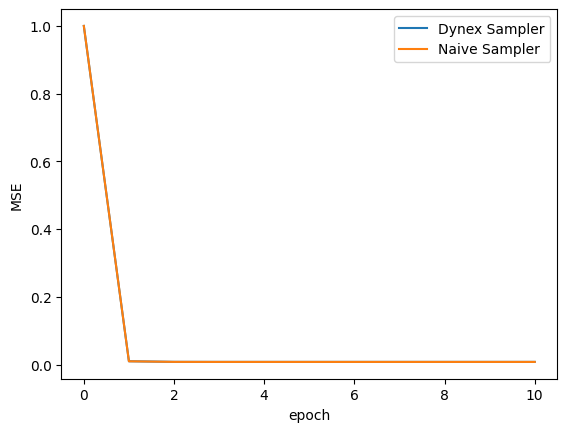

In [ ]:
plt.figure()
plt.plot(dnxErrors, label="Dynex Sampler")
plt.plot(naiveErrors, label="Naive Sampler")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()